In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Validate Gold") \
    .master("local[2]") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 3.5.0


In [2]:
tables = ["hourly_metrics", "daily_metrics", "zone_metrics", 
          "payment_metrics", "weekday_metrics"]

for table in tables:
    df = spark.read.parquet(f"/home/jovyan/data/gold/{table}")
    print(f"\n── {table}: {df.count()} rows ──")
    df.show(3)


── hourly_metrics: 48 rows ──
+------------+-----------+-----------+-----------+-------------+--------+------------+----------------+-----------+--------------+
|pickup_month|pickup_hour|time_of_day|total_trips|total_revenue|avg_fare|avg_distance|avg_duration_min|avg_tip_pct|avg_passengers|
+------------+-----------+-----------+-----------+-------------+--------+------------+----------------+-----------+--------------+
|     2024-01|          0| Late Night|      68803|   1352370.41|   19.66|         3.9|           13.68|      21.23|          1.42|
|     2024-01|          1| Late Night|      45093|    780227.39|    17.3|        3.26|           12.55|      21.73|          1.44|
|     2024-01|          2| Late Night|      31739|    518117.25|   16.32|        3.03|           11.96|      21.71|          1.45|
+------------+-----------+-----------+-----------+-------------+--------+------------+----------------+-----------+--------------+
only showing top 3 rows


── daily_metrics: 60 rows 

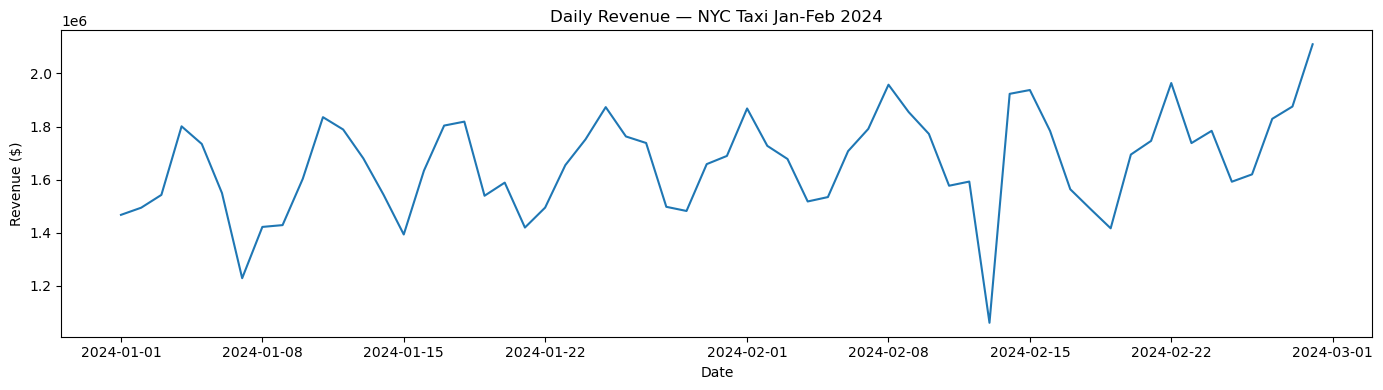

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

daily = spark.read.parquet("/home/jovyan/data/gold/daily_metrics").toPandas()
daily["pickup_date"] = pd.to_datetime(daily["pickup_date"])
daily = daily.sort_values("pickup_date")

plt.figure(figsize=(14, 4))
plt.plot(daily["pickup_date"], daily["total_revenue"])
plt.title("Daily Revenue — NYC Taxi Jan-Feb 2024")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

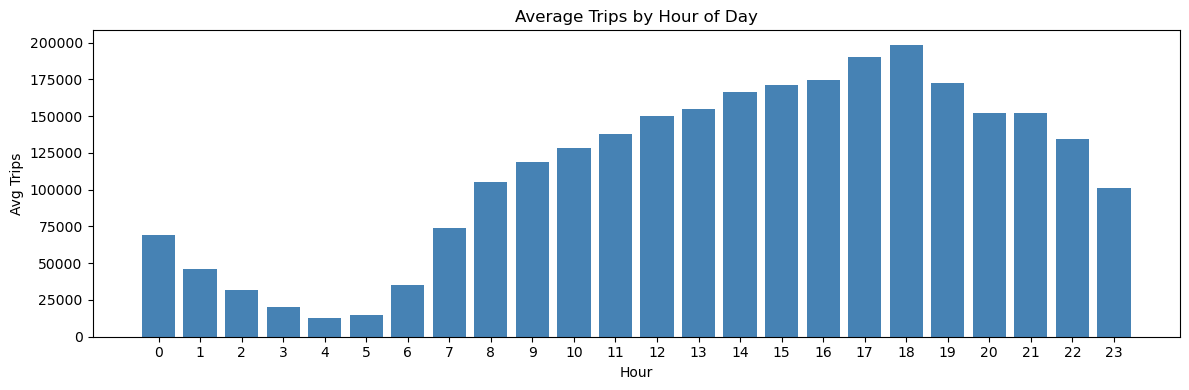

In [4]:
hourly = spark.read.parquet("/home/jovyan/data/gold/hourly_metrics").toPandas()
hourly_avg = hourly.groupby("pickup_hour")["total_trips"].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.bar(hourly_avg["pickup_hour"], hourly_avg["total_trips"], color="steelblue")
plt.title("Average Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Trips")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [5]:
spark.stop()